2026-01-12 02:30:16.148531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/maverick/Library/CloudStorage/OneDrive-Personal/Documents/UNCH/.tf_env/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
/Users/maverick/Library/CloudStorage/OneDrive-Personal/Documents/UNCH/.tf_env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 568933.0625 - val_loss: 740445.1875
Epoch 2/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 557209.6250 - val_loss: 723215.1250
Epoch 3/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 537667.0000 - val_loss: 696607.2500
Epoch 4/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 512828.3125 - val_loss: 665651.2500
Epoch 5/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 486681.8125 - val_loss: 636291.8125
Epoch 6/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 462101.1250 - val_loss: 608557.6250
Epoch 7/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 439460.0000 - val_loss: 583282.4375
Epoch 8/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 419074.7812 - val_loss: 560349.5625
Epoch 9/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 400748.6250 - val_loss: 539526.3750
Epoch 10/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 384192.5000 - val_loss: 520048.5312
Epoch 11/600
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/st

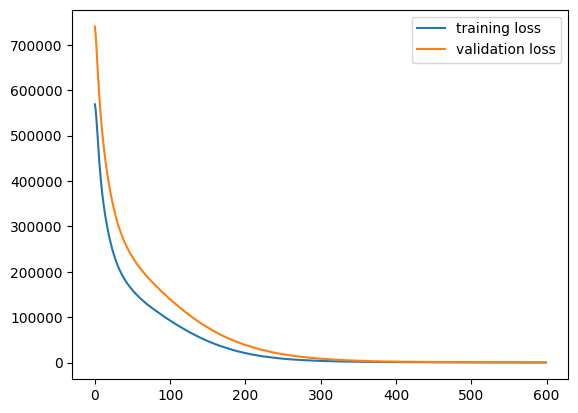

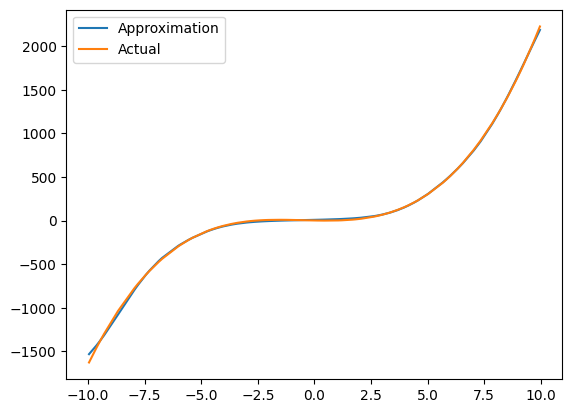

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Define the polynomial function
def polynomial(x):
    return 2 * x**3 + 3 * x**2 - 5 * x + 2

# Generate random training data
np.random.seed(0)
X_train = np.random.uniform(low=-10, high=10, size=(1000,))
y_train = polynomial(X_train)

# Generate random validation data
X_val = np.random.uniform(low=-10, high=10, size=(100,))
y_val = polynomial(X_val)

# Generate random test data
X_test = np.random.uniform(low=-10, high=10, size=(100,))
y_test = polynomial(X_test)

# Define the model
model = keras.Sequential([
    layers.InputLayer(input_shape=[1]),
    layers.Dense(800, activation='sigmoid'),
    layers.Dense(1)
])


# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=600,
    batch_size=16,
    verbose=1
)

# Evaluate the model on the test data
loss = model.evaluate(X_test, y_test)
print('Test loss:', loss)

# Generate test data of actual
# and predicted values for plotting
X_test.sort() #sort list since we picked them randomly
y_plot = polynomial(X_test)
y_pred = model.predict(X_test)

# Plot the development of the loss function during training
plt.figure()
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()


# Plot predicted values and test data
plt.plot(X_test, y_pred, label='Approximation')
plt.plot(X_test, y_plot, label='Actual')
plt.legend()
plt.show()